# Chapter 9 — Modeling probabilities and nonlinearities: activation functions

Chapter ini membahas **activation functions** dan bagaimana fungsi tersebut membantu neural network memodelkan nilai, probabilitas, serta proses backpropagation.

> **Catatan:** Penjelasan teori dan contoh numerik pada notebook ini mengikuti pembahasan *Grokking Deep Learning*, sedangkan visual dibuat ulang agar output lebih mudah dibaca dan tidak monoton.

## Learning Objectives

Setelah menyelesaikan chapter ini, kita dapat:
- memahami peran **activation function** pada sebuah layer;
- membedakan **ReLU, sigmoid, tanh,** dan **softmax**;
- memahami alasan pemilihan activation function untuk hidden layer dan output layer;
- menjelaskan mengapa **softmax** cocok untuk klasifikasi satu-label seperti MNIST;
- memahami hubungan activation function dengan **slope/derivative** pada backpropagation;
- memahami perubahan konfigurasi network pada eksperimen MNIST di akhir chapter.

## Chapter Roadmap

1. What is an activation function?
2. Standard hidden-layer activation functions
3. Standard output layer activation functions
4. The core issue: Inputs have similarity
5. softmax computation
6. Activation installation instructions
7. Multiplying delta by the slope
8. Converting output to slope (derivative)
9. Upgrading the MNIST network
10. Summary

## What is an activation function?

Menurut chapter, **activation function** adalah fungsi yang diterapkan pada neuron sebuah layer selama proses prediction.

Pada chapter sebelumnya kita telah menggunakan **ReLU**. Secara sederhana:

\[
ReLU(x)=
\begin{cases}
x,&x>0\\
0,&x\leq0
\end{cases}
\]

ReLU membuat nilai negatif menjadi 0. Chapter 9 kemudian memperluas pembahasan ini ke fungsi lain yang lebih sesuai untuk kebutuhan tertentu.

Book juga menekankan bahwa activation function yang baik harus memiliki domain yang kontinu dan infinite, serta bersifat monotonic.

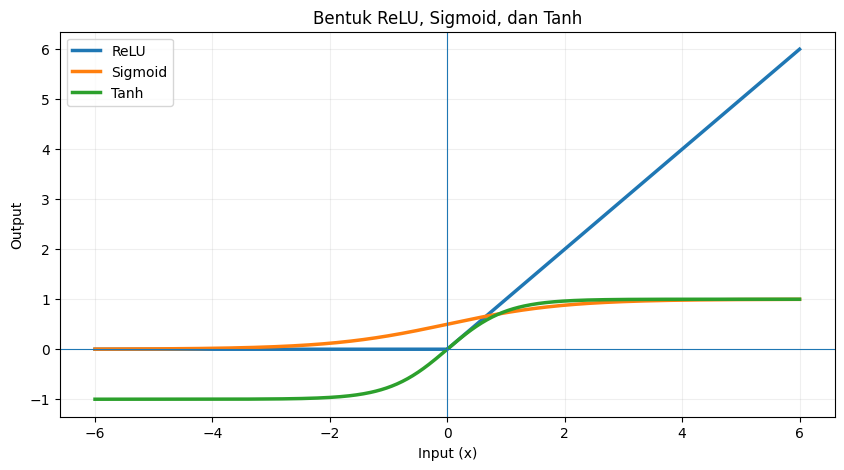

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-6, 6, 400)

relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, relu, label="ReLU", linewidth=2.5)
ax.plot(x, sigmoid, label="Sigmoid", linewidth=2.5)
ax.plot(x, tanh, label="Tanh", linewidth=2.5)
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
ax.set_title("Bentuk ReLU, Sigmoid, dan Tanh")
ax.set_xlabel("Input (x)")
ax.set_ylabel("Output")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

**Interpretasi:** visual ini memperlihatkan bahwa satu input dapat diubah dengan karakteristik yang berbeda. ReLU mempertahankan nilai positif dan memotong nilai negatif menjadi 0, sigmoid memetakan nilai ke rentang 0–1, sedangkan tanh memetakan nilai ke rentang −1 hingga 1. Bentuk fungsi inilah yang menentukan bagaimana informasi diteruskan ke layer berikutnya.

## Standard hidden-layer activation functions

Chapter memperkenalkan dua activation function standar untuk hidden layer:

- **Sigmoid**
  \[
  sigmoid(x)=\frac{1}{1+e^{-x}}
  \]

- **Tanh**
  \[
  tanh(x)=\tanh(x)
  \]

Sigmoid menghasilkan output antara 0 dan 1, sedangkan tanh menghasilkan output antara −1 dan 1.

Keduanya bersifat nonlinear sehingga membantu neural network mempelajari hubungan yang tidak sekadar linear.

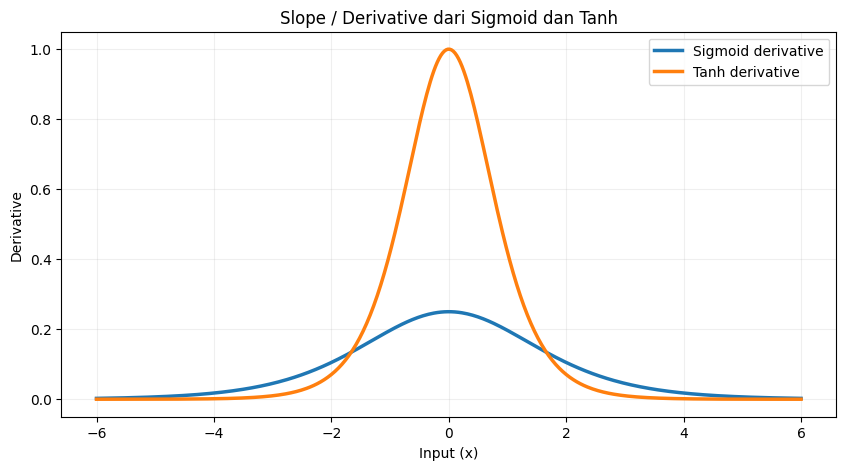

In [2]:
sigmoid_deriv = sigmoid * (1 - sigmoid)
tanh_deriv = 1 - tanh**2

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, sigmoid_deriv, label="Sigmoid derivative", linewidth=2.5)
ax.plot(x, tanh_deriv, label="Tanh derivative", linewidth=2.5)
ax.set_title("Slope / Derivative dari Sigmoid dan Tanh")
ax.set_xlabel("Input (x)")
ax.set_ylabel("Derivative")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

**Interpretasi:** derivative menunjukkan sensitivitas output terhadap perubahan input. Nilai derivative yang kecil berarti perubahan input hanya menghasilkan perubahan output yang kecil. Konsep ini menjadi penting ketika delta dipropagasikan mundur pada backpropagation.

## Standard output layer activation functions

Pemilihan activation function pada output layer bergantung pada jenis prediksi.

| Kebutuhan output | Activation | Contoh |
|---|---|---|
| Raw data values | Tidak menggunakan activation | Prediksi temperatur |
| Beberapa probabilitas yes/no yang terpisah | Sigmoid | Beberapa label binary |
| Memilih satu label dari banyak pilihan | Softmax | Klasifikasi digit MNIST |

Untuk MNIST, hanya **satu digit** yang menjadi label yang benar. Karena itu, softmax lebih sesuai untuk memodelkan hubungan antar-kelas.

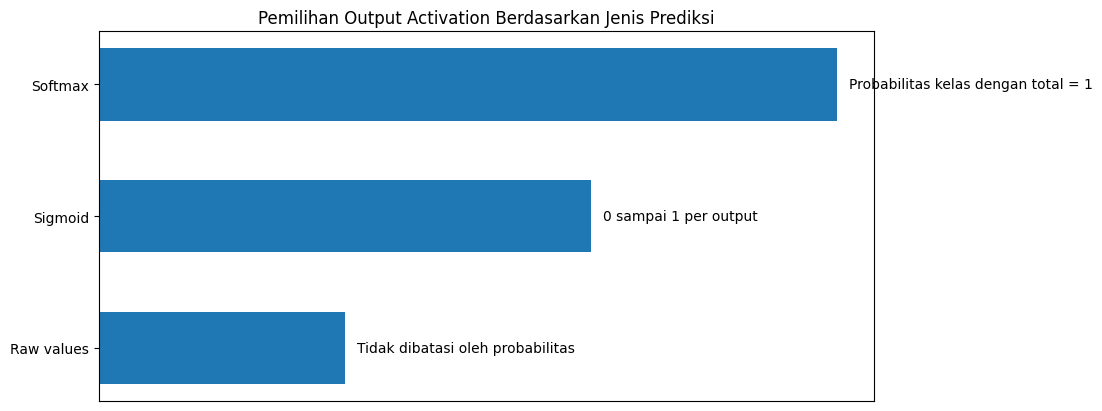

In [3]:
labels = ["Raw values", "Sigmoid", "Softmax"]
ranges = ["Tidak dibatasi oleh probabilitas", "0 sampai 1 per output", "Probabilitas kelas dengan total = 1"]

fig, ax = plt.subplots(figsize=(10, 4.8))
y = np.arange(len(labels))
ax.barh(y, [1, 2, 3], height=0.55)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xticks([])
ax.set_title("Pemilihan Output Activation Berdasarkan Jenis Prediksi")
for i, txt in enumerate(ranges):
    ax.text(i+1.05, i, txt, va="center", fontsize=10)
ax.grid(axis="x", alpha=0.15)
plt.show()

**Catatan akurasi:** panjang bar pada visual di atas **bukan nilai performa model**. Bar hanya dipakai sebagai perangkat visual untuk membedakan tiga konfigurasi output. Informasi teknis yang menjadi dasar tetap berasal dari klasifikasi tiga konfigurasi output pada chapter.

## The core issue: Inputs have similarity

Chapter menjelaskan bahwa input yang berbeda dapat memiliki karakteristik yang sama. Pada MNIST, misalnya, digit **2** dan **3** dapat memiliki sebagian bentuk/stroke yang mirip.

Karena itu, output untuk satu kelas sebaiknya tidak diperlakukan seolah-olah seluruh kelas lain sama sekali tidak berhubungan.

Untuk kasus **which-one classification**, softmax memberikan interpretasi yang lebih sesuai: ketika probabilitas satu kelas meningkat, probabilitas kelas lain ikut terdorong turun karena seluruh probabilitas harus berjumlah 1.

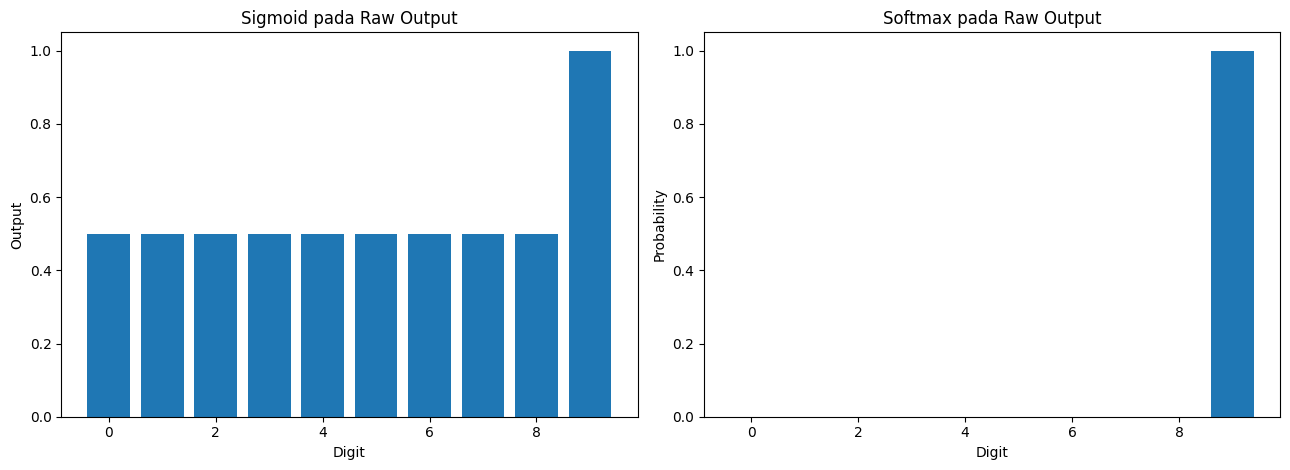

Jumlah probabilitas softmax: 1.0


In [4]:
# Contoh numerik yang persis mengikuti ilustrasi chapter:
# raw output: 0 untuk digit 0-8 dan 100 untuk digit 9
raw = np.array([0.,0.,0.,0.,0.,0.,0.,0.,0.,100.])

sigmoid_out = 1 / (1 + np.exp(-raw))
softmax_out = np.exp(raw) / np.sum(np.exp(raw))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].bar(np.arange(10), sigmoid_out)
axes[0].set_title("Sigmoid pada Raw Output")
axes[0].set_xlabel("Digit")
axes[0].set_ylabel("Output")
axes[0].set_ylim(0, 1.05)

axes[1].bar(np.arange(10), softmax_out)
axes[1].set_title("Softmax pada Raw Output")
axes[1].set_xlabel("Digit")
axes[1].set_ylabel("Probability")
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print("Jumlah probabilitas softmax:", softmax_out.sum())

### Interpretasi hasil

Pada contoh chapter, raw output `[0, 0, ..., 100]` dimaksudkan sebagai prediksi yang sangat kuat untuk digit 9.

- **Sigmoid** menghasilkan sekitar `0.50` pada sembilan output pertama dan sekitar `0.99` pada digit 9.
- **Softmax** menghasilkan `0` pada kelas lain dan `1` pada digit 9 dalam representasi numerik yang ditampilkan chapter.

Hal ini menjelaskan mengapa softmax lebih cocok untuk kasus **single-label classification**: probabilitas diperlakukan sebagai satu distribusi yang saling berkaitan.

In [5]:
# Memeriksa konsep softmax secara eksplisit
print("Softmax output:", np.round(softmax_out, 6))
print("Argmax (kelas terpilih):", np.argmax(softmax_out))
print("Total probability:", softmax_out.sum())

Softmax output: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
Argmax (kelas terpilih): 9
Total probability: 1.0


## softmax computation

Chapter menjelaskan softmax sebagai proses:

1. setiap input dinaikkan secara eksponensial;
2. hasilnya dibagi dengan jumlah seluruh hasil eksponensial.

\[
softmax(x_i)=\frac{e^{x_i}}{\sum_j e^{x_j}}
\]

Dengan demikian, seluruh output softmax membentuk satu distribusi probabilitas dan jumlahnya menjadi 1.

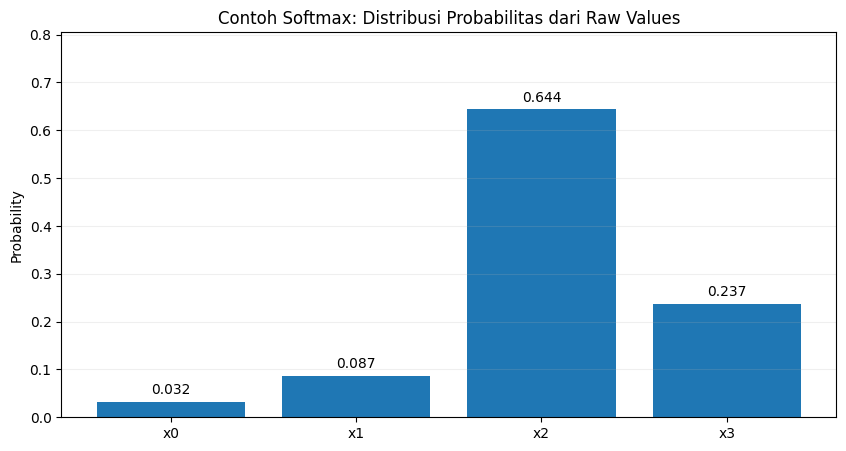

Jumlah probability = 1.0


In [6]:
z = np.array([1.0, 2.0, 4.0, 3.0])
exp_z = np.exp(z)
prob_z = exp_z / exp_z.sum()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(np.arange(len(z)), prob_z)
ax.set_xticks(np.arange(len(z)))
ax.set_xticklabels([f"x{i}" for i in range(len(z))])
ax.set_ylabel("Probability")
ax.set_title("Contoh Softmax: Distribusi Probabilitas dari Raw Values")
ax.set_ylim(0, max(prob_z)*1.25)

for bar, p in zip(bars, prob_z):
    ax.text(bar.get_x() + bar.get_width()/2, p + 0.01, f"{p:.3f}",
            ha="center", va="bottom")

ax.grid(axis="y", alpha=0.2)
plt.show()
print("Jumlah probability =", prob_z.sum())

**Interpretasi:** kelas dengan raw value terbesar mendapatkan probability terbesar. Namun berbeda dari sigmoid, semua kelas tetap berada dalam satu distribusi yang totalnya 1.

## Activation installation instructions

Ketika activation function ditambahkan, proses backpropagation perlu menyesuaikan perhitungan **delta**.

Untuk sebuah hidden layer:

\[
layer\_delta =
backpropagated\_delta \times slope
\]

Artinya, delta yang datang dari layer berikutnya dikalikan dengan slope activation function pada posisi tersebut.

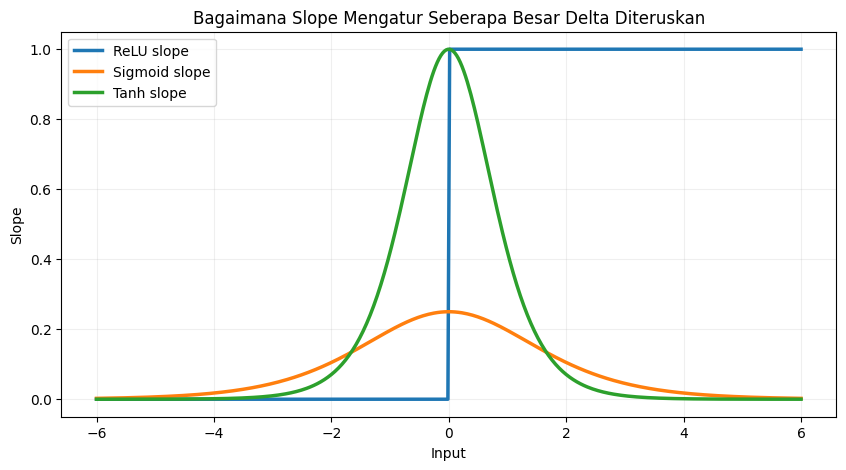

In [7]:
# Visualisasi konseptual yang menggunakan nilai fungsi aktual,
# bukan hasil training model.
relu_slope = (x >= 0).astype(float)
sigmoid_slope = sigmoid_deriv
tanh_slope = tanh_deriv

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, relu_slope, label="ReLU slope", linewidth=2.5)
ax.plot(x, sigmoid_slope, label="Sigmoid slope", linewidth=2.5)
ax.plot(x, tanh_slope, label="Tanh slope", linewidth=2.5)
ax.set_title("Bagaimana Slope Mengatur Seberapa Besar Delta Diteruskan")
ax.set_xlabel("Input")
ax.set_ylabel("Slope")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

**Inti konsep:** jika slope mendekati 0, perubahan kecil pada input memiliki pengaruh kecil terhadap output. Karena itu, backpropagation juga mengurangi pengaruh delta pada posisi tersebut.

## Converting output to slope (derivative)

Chapter menunjukkan bahwa activation function yang umum digunakan dapat menghitung derivative dari output activation itu sendiri.

| Function | Forward propagation | Derivative |
|---|---|---|
| ReLU | `output = input * (input > 0)` | `output > 0` |
| Sigmoid | `1 / (1 + exp(-input))` | `output * (1-output)` |
| Tanh | `tanh(input)` | `1 - output²` |
| Softmax | `exp(input) / sum(exp(input))` | Memiliki delta khusus pada output layer |

Untuk softmax, chapter secara eksplisit menyebut bahwa delta-nya bersifat khusus dan digunakan pada output layer.

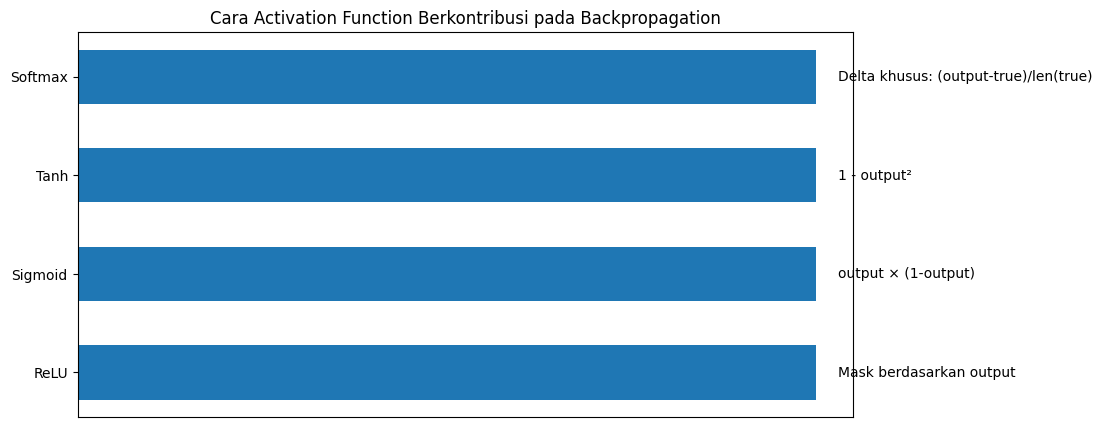

In [8]:
functions = ["ReLU", "Sigmoid", "Tanh", "Softmax"]
backprop_role = [
    "Mask berdasarkan output",
    "output × (1-output)",
    "1 - output²",
    "Delta khusus: (output-true)/len(true)"
]

fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(functions))
ax.barh(y, [1, 1, 1, 1], height=0.55)
ax.set_yticks(y)
ax.set_yticklabels(functions)
ax.set_xticks([])
ax.set_title("Cara Activation Function Berkontribusi pada Backpropagation")

for i, txt in enumerate(backprop_role):
    ax.text(1.03, i, txt, va="center")

ax.grid(axis="x", alpha=0.15)
plt.show()

## Upgrading the MNIST network

Chapter kemudian mengganti:
- hidden-layer activation: **ReLU → tanh**
- output-layer activation: **raw output → softmax**

Selain mengganti activation, beberapa hyperparameter juga disesuaikan. Chapter menyebut:
- inisialisasi `weights_0_1` dipersempit dari rentang sekitar `[-0.1, 0.1]` menjadi `[-0.01, 0.01]` untuk tanh;
- `alpha` dinaikkan menjadi `2`;
- `iterations = 300`;
- `hidden_size = 100`;
- `batch_size = 100`;
- error calculation dihilangkan dari eksperimen ini karena softmax secara teoritis paling cocok dengan cross entropy, yang belum dibahas penuh pada chapter ini.

In [9]:
# Ringkasan konfigurasi eksperimen akhir Chapter 9
config = {
    "Hidden activation": "tanh",
    "Output activation": "softmax",
    "alpha": 2,
    "iterations": 300,
    "hidden_size": 100,
    "batch_size": 100,
    "weight_0_1 range": "approximately [-0.01, 0.01]",
    "weight_1_2 range": "approximately [-0.1, 0.1]"
}

for k, v in config.items():
    print(f"{k:22s}: {v}")

Hidden activation     : tanh
Output activation     : softmax
alpha                 : 2
iterations            : 300
hidden_size           : 100
batch_size            : 100
weight_0_1 range      : approximately [-0.01, 0.01]
weight_1_2 range      : approximately [-0.1, 0.1]


## Arsitektur eksperimen MNIST

Perubahan utama pada network dapat diringkas sebagai berikut:

**MNIST image (784 pixels) → tanh hidden layer (100 nodes) → softmax output (10 classes)**

Output terdiri dari 10 kelas digit, yaitu `0–9`. Softmax digunakan agar output tersebut dapat dipahami sebagai satu distribusi probabilitas antar-kelas.

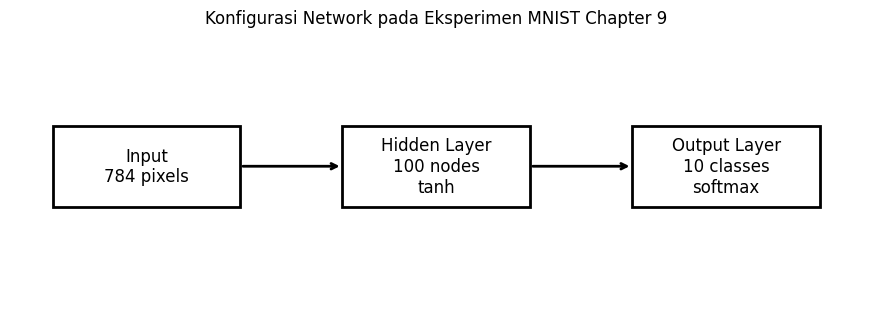

In [10]:
# Diagram sederhana arsitektur akhir Chapter 9
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.axis("off")

boxes = [
    (0.05, 0.35, 0.22, 0.30, "Input\n784 pixels"),
    (0.39, 0.35, 0.22, 0.30, "Hidden Layer\n100 nodes\ntanh"),
    (0.73, 0.35, 0.22, 0.30, "Output Layer\n10 classes\nsoftmax")
]

for x0, y0, w, h, label in boxes:
    ax.add_patch(plt.Rectangle((x0,y0),w,h, fill=False, linewidth=2))
    ax.text(x0+w/2, y0+h/2, label, ha="center", va="center", fontsize=12)

ax.annotate("", xy=(0.39,0.50), xytext=(0.27,0.50),
            arrowprops=dict(arrowstyle="->", linewidth=2))
ax.annotate("", xy=(0.73,0.50), xytext=(0.61,0.50),
            arrowprops=dict(arrowstyle="->", linewidth=2))

ax.set_title("Konfigurasi Network pada Eksperimen MNIST Chapter 9")
plt.show()

## Code reproduction — Upgrading the MNIST network

Cell berikut mempertahankan struktur kode dari chapter. **Cell ini merupakan reproduction source code**, bukan hasil modifikasi untuk membuat visual.

Karena eksekusi membutuhkan dataset MNIST melalui Keras/TensorFlow, cell diberi flag agar tidak otomatis menjalankan download dataset pada environment notebook ini. Dengan demikian, kode tetap tersedia untuk direproduksi di Google Colab.

In [11]:
# Source reproduction is intentionally not auto-executed in this environment.
# Run the original code in Google Colab with TensorFlow/Keras available.

### Hasil yang dilaporkan oleh book

Chapter menyatakan bahwa setelah menggunakan **tanh** pada hidden layer dan **softmax** pada output layer, network mencapai **testing accuracy sekitar 87%** dalam 300 iterations.

Angka ini adalah **hasil yang dilaporkan di book**, bukan hasil eksekusi ulang pada environment pembuatan notebook.

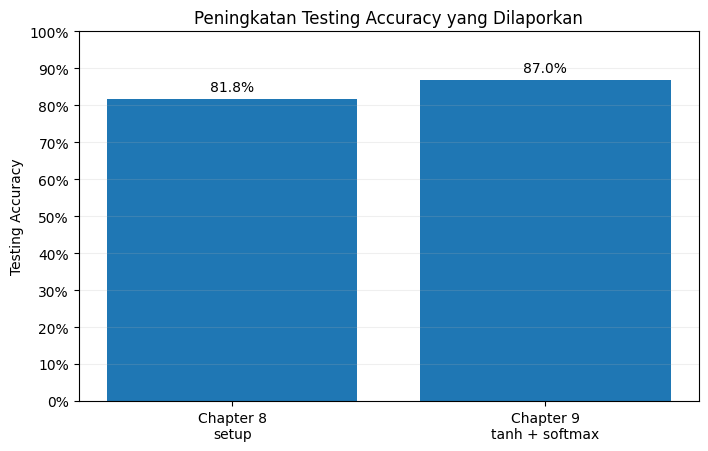

In [12]:
reported_accuracy = 0.87

fig, ax = plt.subplots(figsize=(8, 4.8))
bar = ax.bar(["Chapter 8\nsetup", "Chapter 9\ntanh + softmax"], [0.8181, reported_accuracy])
ax.set_ylim(0, 1)
ax.set_ylabel("Testing Accuracy")
ax.set_title("Peningkatan Testing Accuracy yang Dilaporkan")
ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.set_yticklabels([f"{v:.0%}" for v in np.arange(0, 1.01, 0.1)])

for b, v in zip(bar, [0.8181, reported_accuracy]):
    ax.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.1%}", ha="center")

ax.grid(axis="y", alpha=0.2)
plt.show()

**Catatan penting tentang perbandingan:** nilai sekitar **81.81%** berasal dari hasil akhir eksperimen dropout pada Chapter 8, sedangkan sekitar **87%** adalah hasil yang dilaporkan Chapter 9 setelah upgrade activation functions. Perbandingan ini dipakai untuk menunjukkan konteks peningkatan yang dibahas book; bukan klaim bahwa kedua eksperimen identik dalam seluruh kondisi training.

## Concept Check

**1. Mengapa softmax cocok untuk MNIST?**  
Karena MNIST pada eksperimen ini memilih satu digit dari beberapa kelas. Softmax memodelkan output sebagai satu distribusi probabilitas.

**2. Apa perbedaan utama sigmoid dan tanh?**  
Sigmoid menghasilkan nilai antara 0 dan 1, sedangkan tanh menghasilkan nilai antara −1 dan 1.

**3. Mengapa derivative diperlukan?**  
Derivative/slope digunakan untuk menyesuaikan delta pada backpropagation sehingga besarnya perubahan mengikuti sensitivitas activation function.

**4. Mengapa konfigurasi output tidak selalu menggunakan activation yang sama dengan hidden layer?**  
Karena kebutuhan output berbeda. Hidden layer membutuhkan transformasi yang membantu pembelajaran representasi, sedangkan output layer harus menghasilkan bentuk prediksi yang sesuai dengan task.

## Key Takeaways

- **Activation function** menentukan bagaimana nilai neuron ditransformasikan.
- **ReLU, sigmoid, dan tanh** memiliki karakteristik output dan slope yang berbeda.
- **Sigmoid** cocok untuk probabilitas binary yang relatif independen.
- **Softmax** cocok untuk memilih satu kelas dari banyak kelas.
- Softmax menghasilkan probabilitas yang **jumlahnya 1**.
- Penambahan activation function mengubah cara **delta** dihitung saat backpropagation.
- Chapter 9 mengganti hidden activation menjadi **tanh** dan output activation menjadi **softmax**.
- Book melaporkan bahwa konfigurasi tersebut mencapai **testing accuracy sekitar 87%** pada eksperimen MNIST.

## Chapter Summary

Chapter 9 memperkenalkan activation functions sebagai komponen penting dalam neural network. Pembahasan dimulai dari karakteristik activation function, kemudian sigmoid dan tanh untuk hidden layer, serta tiga jenis kebutuhan output layer termasuk softmax.

Bagian penting lainnya adalah hubungan activation function dengan slope pada backpropagation. Pada eksperimen akhir, network MNIST di-upgrade menggunakan **tanh + softmax**, dengan penyesuaian weight initialization dan learning rate. Book melaporkan testing accuracy sekitar **87%**, menunjukkan bahwa pemilihan activation function dapat memengaruhi kualitas prediksi.

## Reference

Trask, A. W. *Grokking Deep Learning*. Manning Publications.

**Source coverage:** Chapter 9, pp. 161–175, khususnya bagian *What is an activation function?*, *Standard hidden-layer activation functions*, *Standard output layer activation functions*, *The core issue: Inputs have similarity*, *softmax computation*, *Activation installation instructions*, *Multiplying delta by the slope*, *Converting output to slope (derivative)*, dan *Upgrading the MNIST network*.